In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Keepalive — run this in a separate cell to prevent idle disconnection:
%%javascript
window.keepAliveInterval = setInterval(function(){
    console.log("Keeping alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}, 60000)

<IPython.core.display.Javascript object>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 90.0 MB/s eta 0:00:00

CONDITION: Sentence-Level
Loading 360 files | Condition: Sentence-Level
  File 1/360...
  File 21/360...
  File 41/360...
  File 61/360...
  File 81/360...
  File 101/360...
  File 121/360...
  File 141/360...
  File 161/360...
  File 181/360...
  File 201/360...
  File 221/360...
  File 241/360...
  File 261/360...
  File 281/360...
  File 301/360...
  File 321/360...
  File 341/360...
Loaded: 360 samples | Skipped: 0

Class dist:
Angry        48
Calm         48
Disgust      48
Fearful      48
Happy        48
Neutral      24
Sad          48
Surprised    48

  Random Forest... Acc: 0.439 | F1: 0.385 | Time: 3.2s
  MLP_3Layer... 

Acc: 0.389 | F1: 0.331 | Time: 50.5s

CONDITION: 2s-Windows
Loading 360 files | Condition: 2s-Windows
  File 1/360...
  File 21/360...
  File 41/360...
  File 61/360...
  File 81/360...
  File 101/360...
  File 121/360...
  File 141/360...
  File 161/360...
  File 181/360...
  File 201/360...
  File 221/360...
  File 241/360...
  File 261/360...
  File 281/360...
  File 301/360...
  File 321/360...
  File 341/360...
Loaded: 426 samples | Skipped: 0

Class dist:
Angry        66
Calm         65
Disgust      64
Fearful      50
Happy        58
Neutral      25
Sad          48
Surprised    50

  Random Forest... Acc: 0.418 | F1: 0.336 | Time: 2.6s
  MLP_3Layer... Acc: 0.430 | F1: 0.347 | Time: 51.9s

CONDITION: 1s-Windows
Loading 360 files | Condition: 1s-Windows
  File 1/360...
  File 21/360...
  File 41/360...
  File 61/360...
  File 81/360...
  File 101/360...
  File 121/360...
  File 141/360...
  File 161/360...
  File 181/360...
  File 201/360...
  File 221/360...
  File 241/360...
  Fi

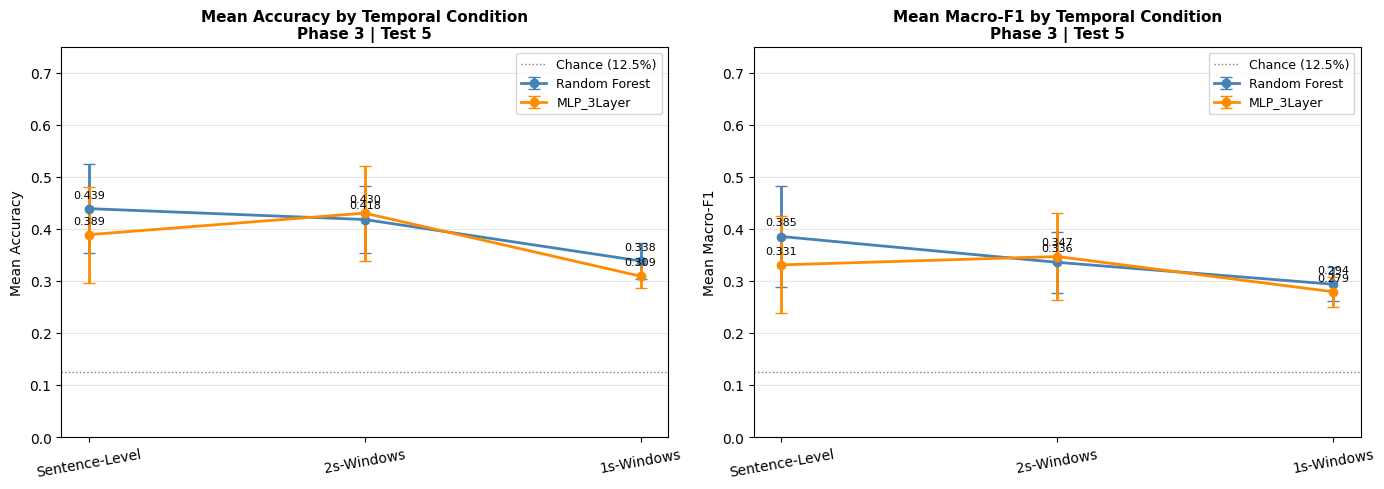

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_temporal_comparison_line.png


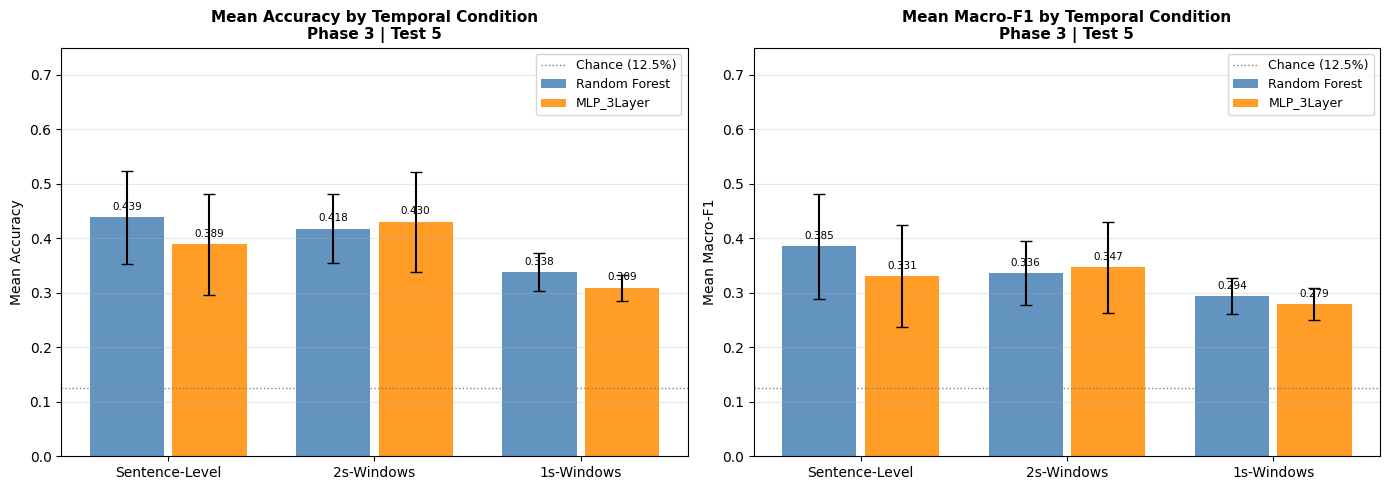

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_temporal_comparison_bar.png


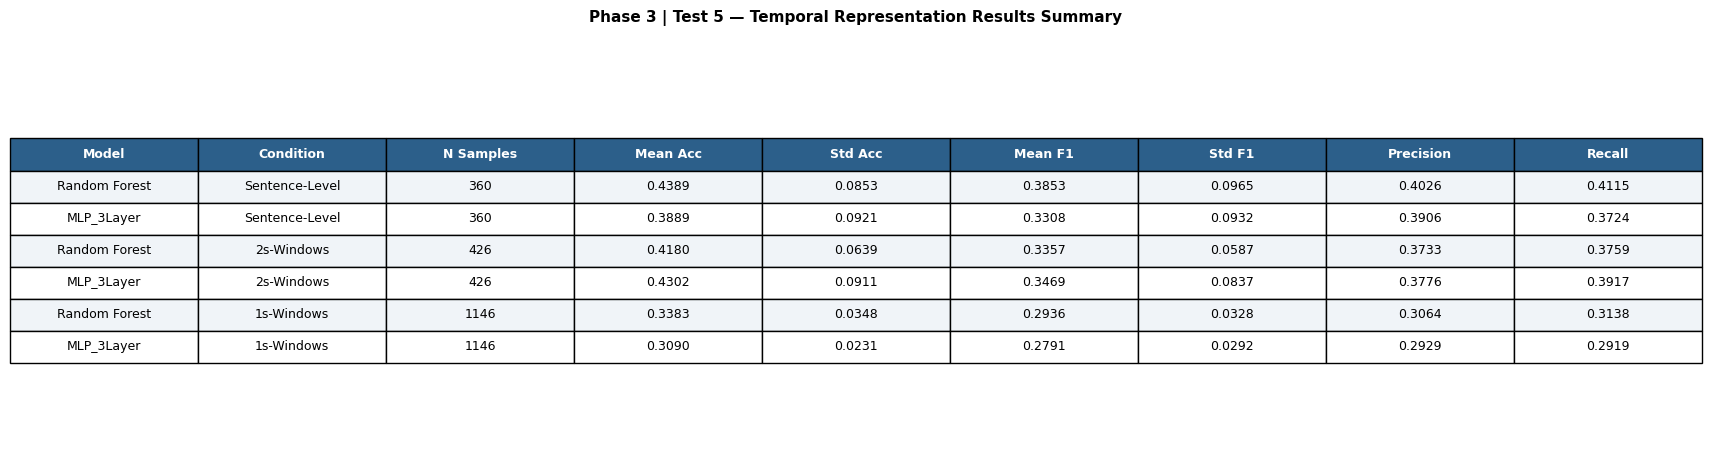

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_results_table.png


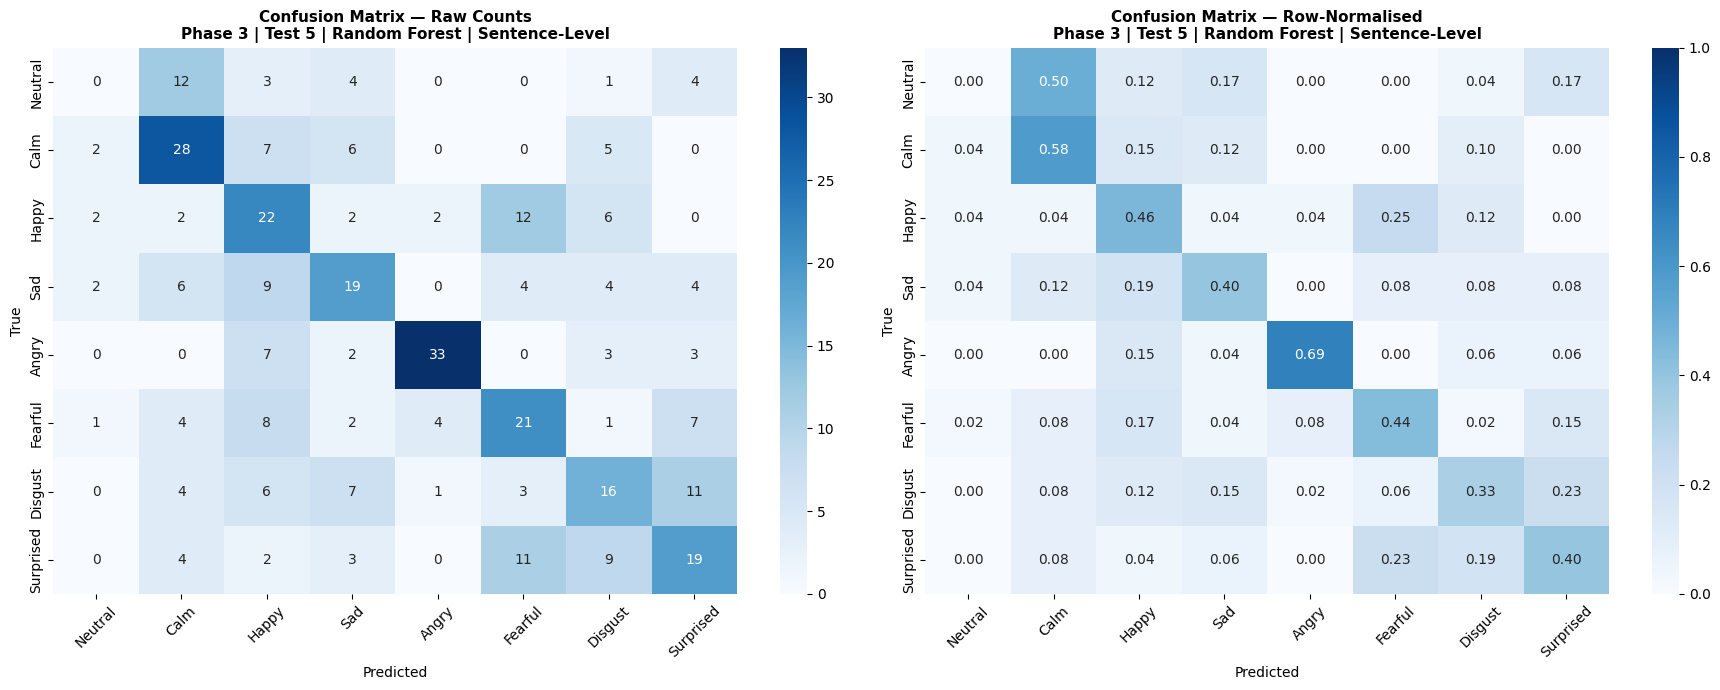

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_CM_Random_Forest_Sentence-Level.png


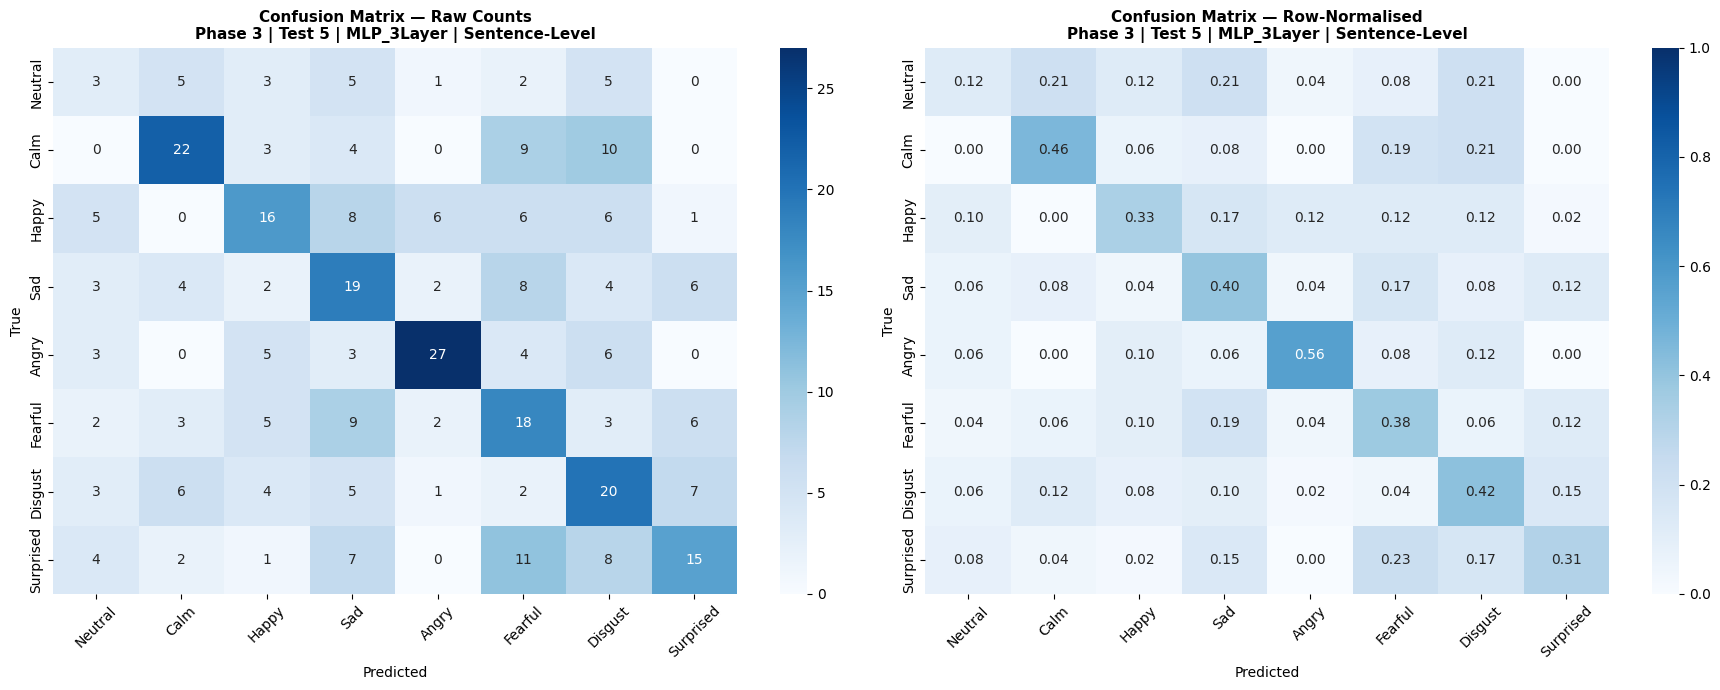

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_CM_MLP_3Layer_Sentence-Level.png


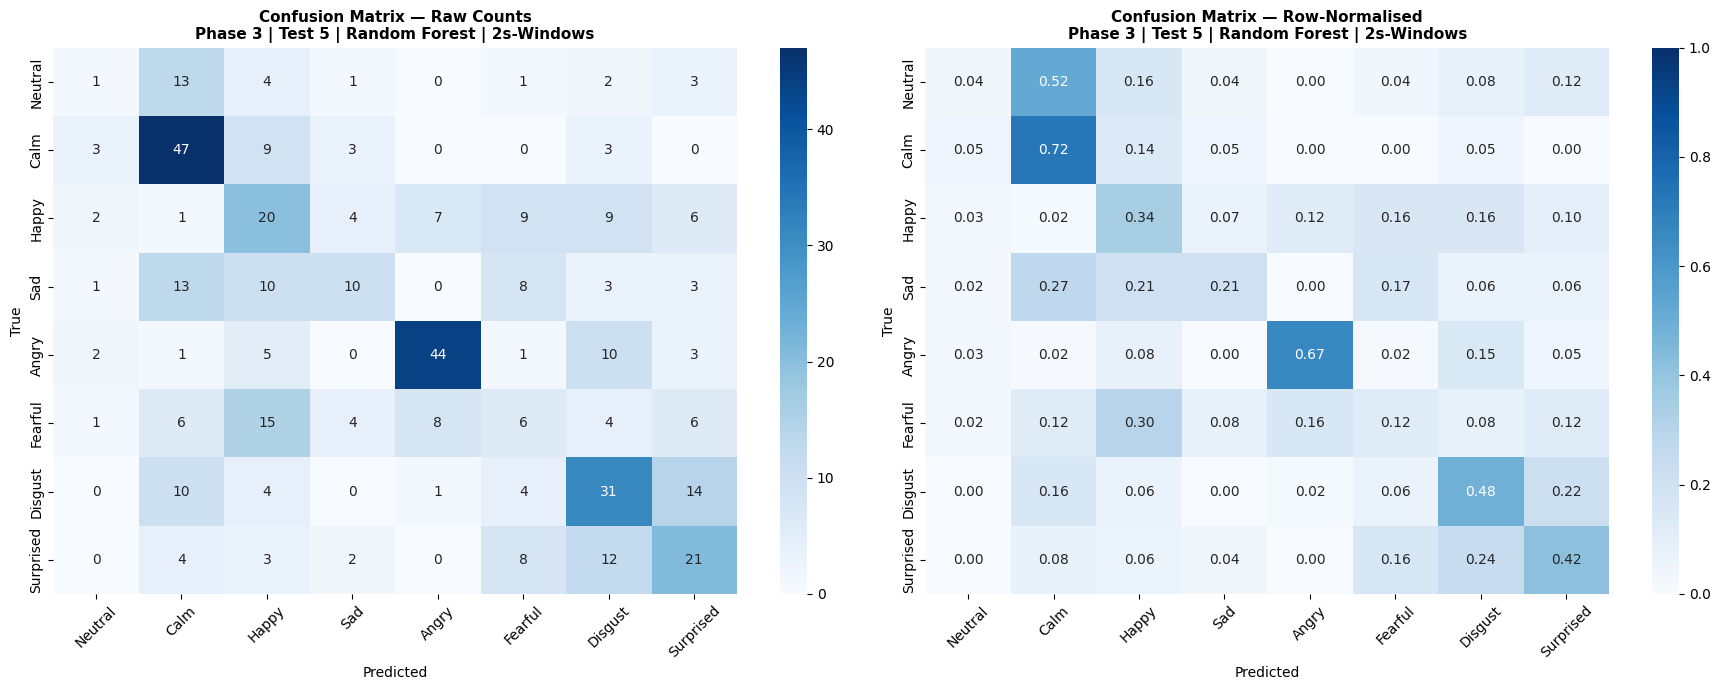

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_CM_Random_Forest_2s-Windows.png


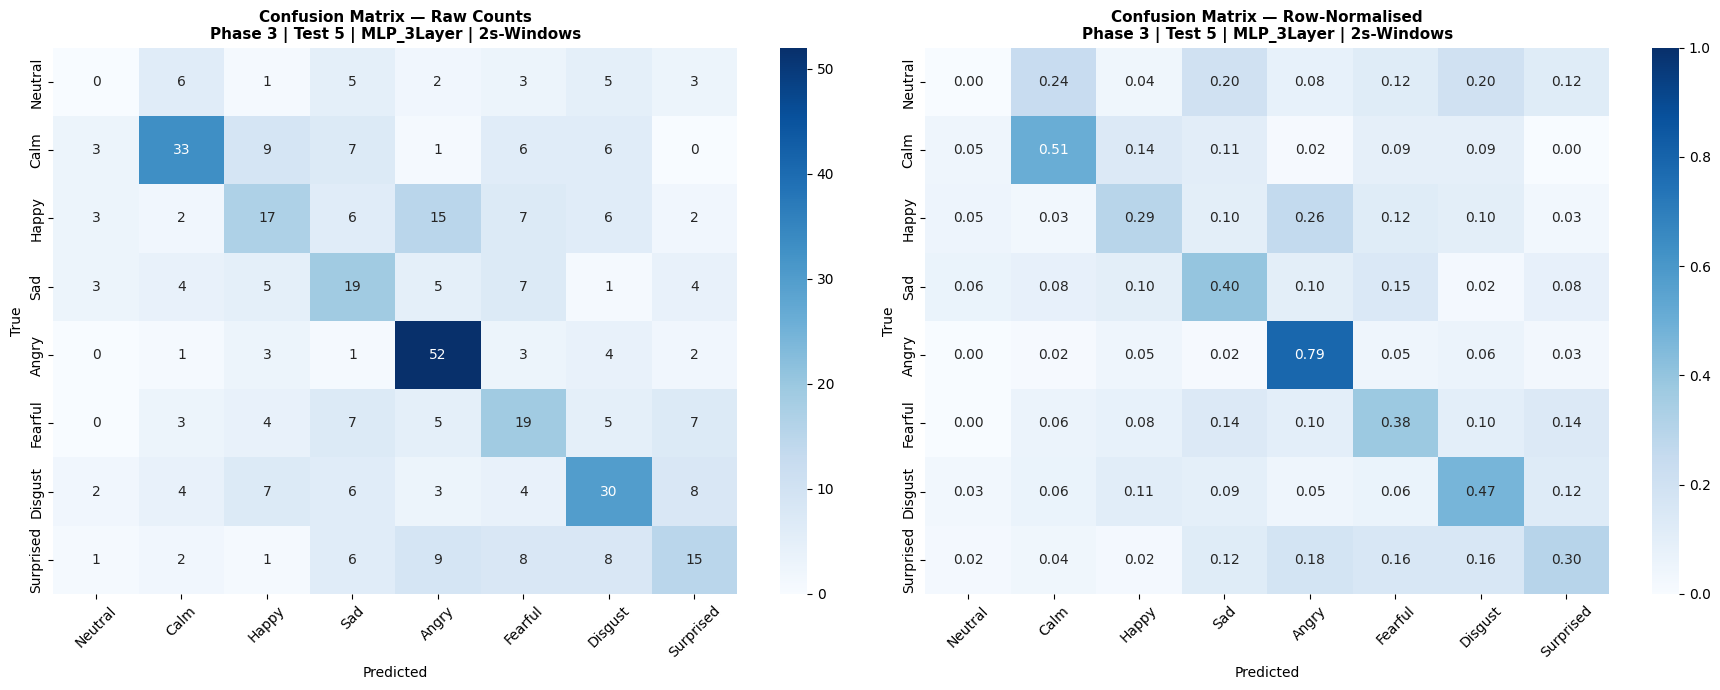

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_CM_MLP_3Layer_2s-Windows.png


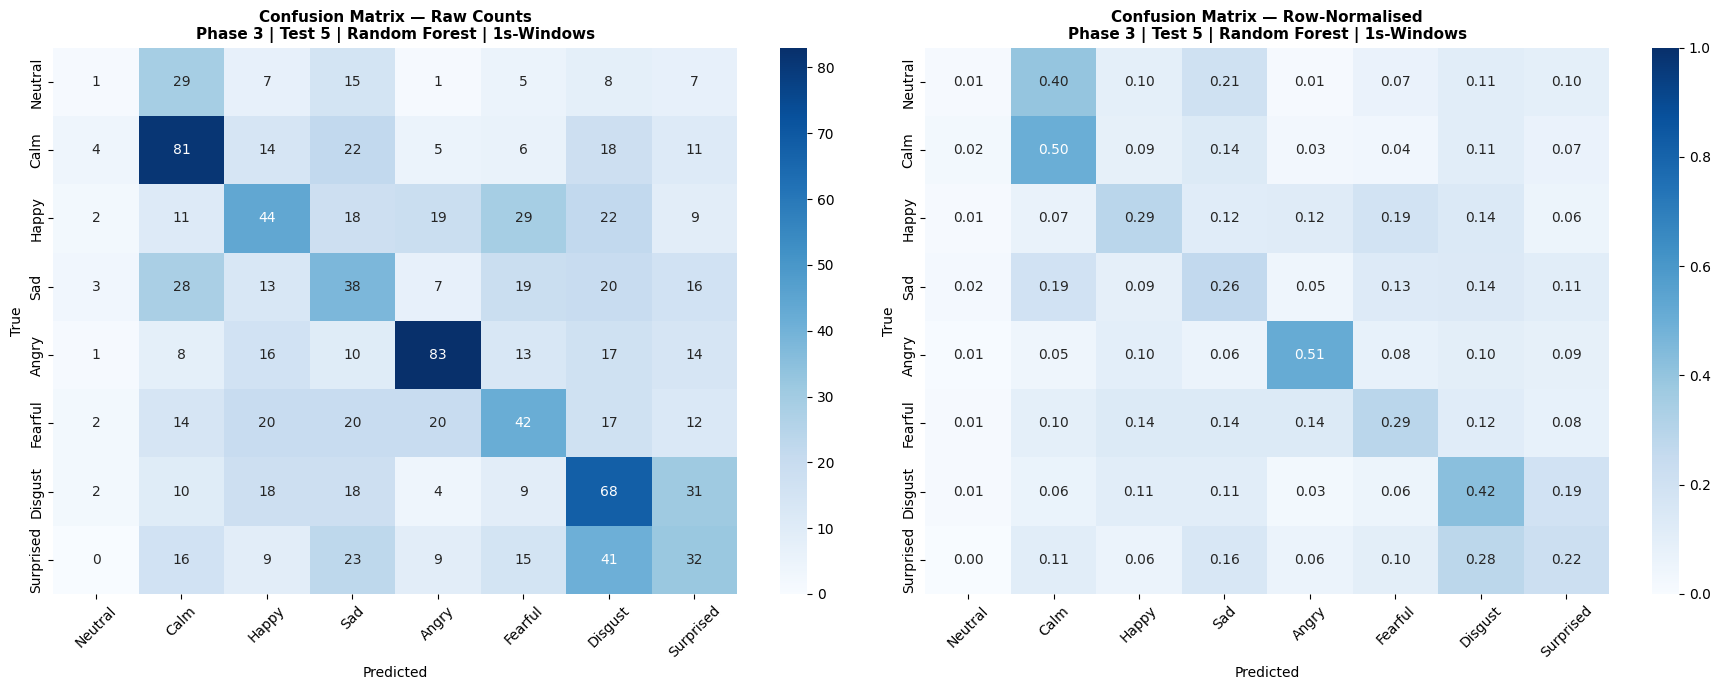

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_CM_Random_Forest_1s-Windows.png


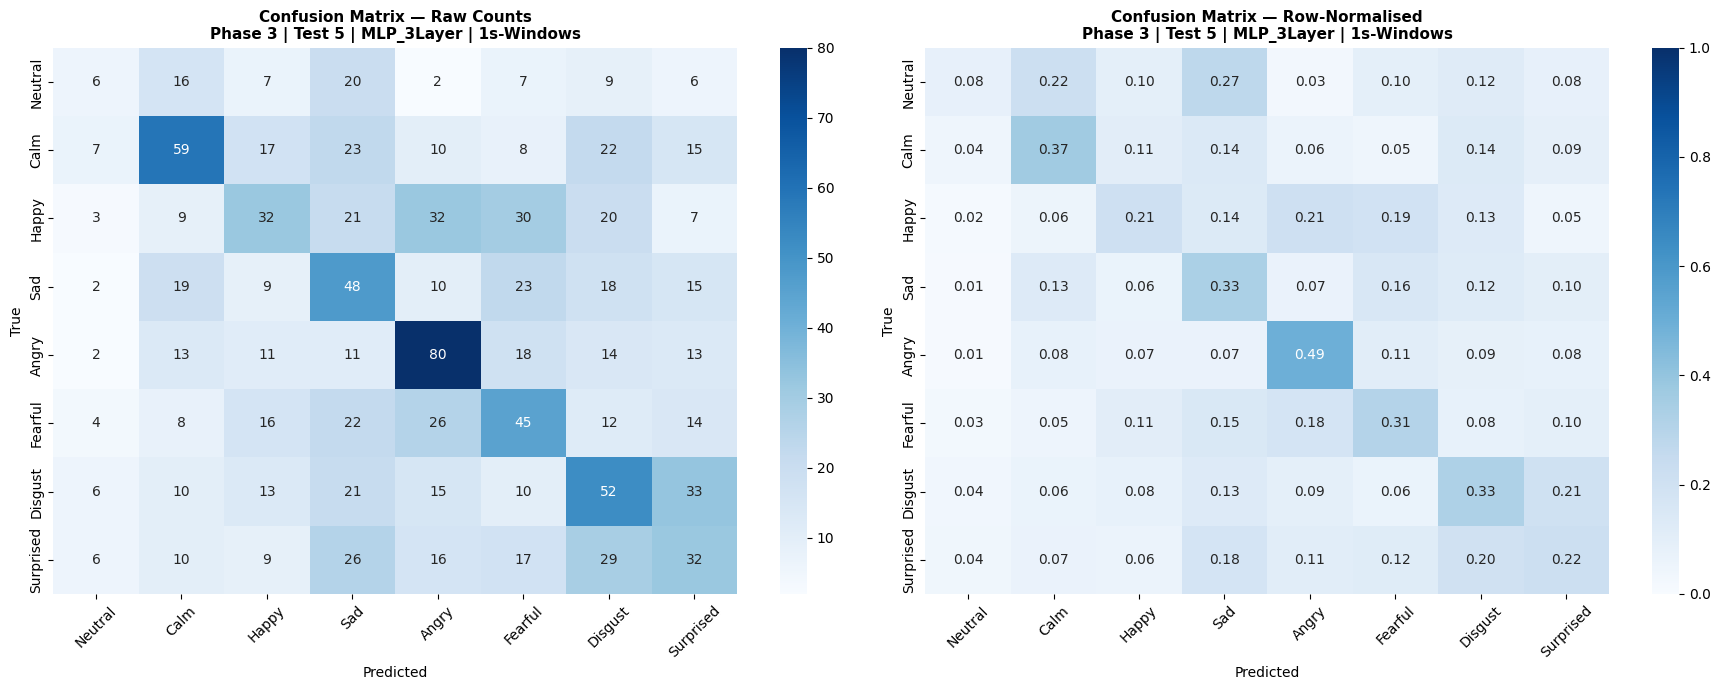

Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_CM_MLP_3Layer_1s-Windows.png
Saved: /content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/P3_T5_summary.csv

Done. Phase 3 complete — all experiments finished.


In [ ]:
# =============================================================================
# DAVIS - Phase 3, Test 5: Temporal Representation Comparison
# Goal: Confirm the best temporal segmentation using the best classical
#       and best neural model from Phase 2
# Models: Random Forest (best classical), MLP_3Layer (best neural)
# Conditions: Sentence-level | 2s windows | 1s windows
# Features: All 41 features (locked from Phase 1)
#
# All outputs saved directly to OUTPUT_DIR on Drive.
# =============================================================================

# Required installs (run once in Colab if not already installed):
!pip install librosa praat-parselmouth soundfile scikit-learn pandas matplotlib seaborn
!pip install tensorflow

# Mount Google Drive first:
# from google.colab import drive
# drive.mount('/content/drive')

import os
import time
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
import soundfile as sf
from parselmouth.praat import call

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# =============================================================================
# CONFIGURATION
# =============================================================================

DATASET_PATH    = "/content/drive/My Drive/Neuroscience/Research/ravdess_male"
SAMPLE_RATE     = 16000
RANDOM_STATE    = 42
VALIDATION_SPLIT    = 0.15
NEURAL_EPOCHS       = 50
NEURAL_BATCH_SIZE   = 32
EARLY_STOP_PATIENCE = 7

OUTPUT_DIR = "/content/drive/My Drive/DAVIS/DAVIS2_results/P3T5/"

emotion_map = {
    "01": "Neutral", "02": "Calm",    "03": "Happy",    "04": "Sad",
    "05": "Angry",   "06": "Fearful", "07": "Disgust",  "08": "Surprised",
}
EMOTION_LABELS = list(emotion_map.values())
N_CLASSES      = len(EMOTION_LABELS)

# Temporal conditions to test
# Each entry: (label, window_sec)
# window_sec = None means sentence-level (full clip, no windowing)
TEMPORAL_CONDITIONS = [
    ("Sentence-Level",          None),
    ("2s-Windows",              2),
    ("1s-Windows",              1),
]

# =============================================================================
# OUTPUT HELPER
# =============================================================================

def out(filename):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    return os.path.join(OUTPUT_DIR, filename)

# =============================================================================
# FEATURE EXTRACTION  (identical pipeline throughout)
# =============================================================================

def extract_parselmouth_features(y, sr):
    temp_filename = "temp_praat.wav"
    try:
        sf.write(temp_filename, y, sr)
        snd           = parselmouth.Sound(temp_filename)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter        = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer       = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        harmonicity   = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr           = call(harmonicity, "Get mean", 0, 0)
        jitter  = 0.0 if (jitter  is None or not np.isfinite(jitter))  else float(jitter)
        shimmer = 0.0 if (shimmer is None or not np.isfinite(shimmer)) else float(shimmer)
        hnr     = 0.0 if (hnr     is None or not np.isfinite(hnr))     else float(hnr)
    except Exception:
        jitter, shimmer, hnr = 0.0, 0.0, 0.0
    finally:
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
    return [jitter, shimmer, hnr]


def extract_features(y_clip, sr):
    MIN_SAMPLES = int(0.1 * sr)
    if len(y_clip) < MIN_SAMPLES or np.max(np.abs(y_clip)) < 1e-6:
        return None

    mfccs      = librosa.feature.mfcc(y=y_clip, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_std  = np.std(mfccs, axis=1)

    pitches, magnitudes = librosa.piptrack(y=y_clip, sr=sr)
    med = np.median(magnitudes)
    valid_pitches = pitches[magnitudes > med] if med > 0 else np.array([])
    valid_pitches = valid_pitches[valid_pitches > 0]
    pitch_mean  = float(np.mean(valid_pitches))  if len(valid_pitches) > 0 else 0.0
    pitch_std   = float(np.std(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_min   = float(np.min(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_max   = float(np.max(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_range = pitch_max - pitch_min

    energy       = librosa.feature.rms(y=y_clip)[0]
    energy_mean  = np.mean(energy)
    energy_std   = np.std(energy)
    energy_min   = np.min(energy)
    energy_max   = np.max(energy)
    energy_range = energy_max - energy_min

    zcr      = librosa.feature.zero_crossing_rate(y_clip)[0]
    zcr_mean = np.mean(zcr)
    zcr_std  = np.std(zcr)

    jitter, shimmer, hnr = extract_parselmouth_features(y_clip, sr)

    features = np.hstack([
        mfccs_mean, mfccs_std,
        [pitch_mean, pitch_std, pitch_min, pitch_max, pitch_range],
        [energy_mean, energy_std, energy_min, energy_max, energy_range],
        [zcr_mean, zcr_std],
        [jitter, shimmer, hnr]
    ])
    return np.where(np.isfinite(features), features, 0.0)

# =============================================================================
# DATA LOADING — parameterised by window size
# =============================================================================

def load_dataset(dataset_path, sr, window_sec, condition_label):
    """
    Load RAVDESS files segmented according to window_sec.
    window_sec = None  →  sentence-level (full clip per file)
    window_sec = int   →  fixed non-overlapping windows
    """
    X, y, actors  = [], [], []
    skipped       = 0

    files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".wav")])
    print(f"Loading {len(files)} files | Condition: {condition_label}")

    for i, file in enumerate(files):
        if i % 20 == 0:
            print(f"  File {i+1}/{len(files)}...")

        parts      = file.split('-')
        emotion_id = parts[2]
        actor_id   = parts[-1].split('.')[0]
        emotion    = emotion_map.get(emotion_id, "Unknown")
        if emotion == "Unknown":
            continue

        y_full, _ = librosa.load(os.path.join(dataset_path, file), sr=sr)

        if window_sec is None:
            features = extract_features(y_full, sr)
            if features is None:
                skipped += 1
                continue
            X.append(features)
            y.append(emotion)
            actors.append(actor_id)
        else:
            spw = int(window_sec * sr)
            for w in range(len(y_full) // spw):
                clip     = y_full[w*spw:(w+1)*spw]
                features = extract_features(clip, sr)
                if features is None:
                    skipped += 1
                    continue
                X.append(features)
                y.append(emotion)
                actors.append(actor_id)

    print(f"Loaded: {len(X)} samples | Skipped: {skipped}\n")
    return np.array(X), np.array(y), np.array(actors)

# =============================================================================
# MODEL BUILDERS
# =============================================================================

def build_mlp_3layer(input_dim, n_classes):
    inputs = Input(shape=(input_dim,))
    x = Dense(256, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    return Model(inputs, outputs, name="MLP_3Layer")

# =============================================================================
# LOOCV RUNNERS
# =============================================================================

def run_loocv_rf(X, y, actors, condition_label):
    unique_actors  = np.unique(actors)
    all_y_true, all_y_pred = [], []
    fold_metrics   = []

    for test_actor in unique_actors:
        train_idx = np.where(actors != test_actor)[0]
        test_idx  = np.where(actors == test_actor)[0]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler     = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        model = RandomForestClassifier(
            n_estimators=200, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        fold_metrics.append({
            'actor':    test_actor,
            'accuracy': accuracy_score(y_test, y_pred),
            'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        })
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    accs = [m['accuracy'] for m in fold_metrics]
    f1s  = [m['macro_f1'] for m in fold_metrics]

    return {
        'model':          'Random Forest',
        'condition':      condition_label,
        'n_samples':      len(X),
        'mean_accuracy':  np.mean(accs),
        'std_accuracy':   np.std(accs),
        'mean_macro_f1':  np.mean(f1s),
        'std_macro_f1':   np.std(f1s),
        'mean_precision': precision_score(all_y_true, all_y_pred,
                                          average='macro', zero_division=0),
        'mean_recall':    recall_score(all_y_true, all_y_pred,
                                       average='macro', zero_division=0),
    }, np.array(all_y_true), np.array(all_y_pred)


def run_loocv_mlp(X, y, actors, le, condition_label):
    unique_actors  = np.unique(actors)
    input_dim      = X.shape[1]
    all_y_true, all_y_pred = [], []
    fold_metrics   = []

    for test_actor in unique_actors:
        train_idx = np.where(actors != test_actor)[0]
        test_idx  = np.where(actors == test_actor)[0]

        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]

        scaler     = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train_full)
        X_test_sc  = scaler.transform(X_test)

        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train_sc, y_train_full,
            test_size=VALIDATION_SPLIT,
            stratify=y_train_full,
            random_state=RANDOM_STATE
        )

        y_tr_enc  = to_categorical(le.transform(y_tr),  N_CLASSES)
        y_val_enc = to_categorical(le.transform(y_val), N_CLASSES)

        tf.keras.backend.clear_session()
        model = build_mlp_3layer(input_dim, N_CLASSES)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss', patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=0
        )
        model.fit(
            X_tr, y_tr_enc,
            validation_data=(X_val, y_val_enc),
            epochs=NEURAL_EPOCHS,
            batch_size=NEURAL_BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        y_pred = le.inverse_transform(
            np.argmax(model.predict(X_test_sc, verbose=0), axis=1)
        )

        fold_metrics.append({
            'actor':    test_actor,
            'accuracy': accuracy_score(y_test, y_pred),
            'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        })
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    accs = [m['accuracy'] for m in fold_metrics]
    f1s  = [m['macro_f1'] for m in fold_metrics]

    return {
        'model':          'MLP_3Layer',
        'condition':      condition_label,
        'n_samples':      len(X),
        'mean_accuracy':  np.mean(accs),
        'std_accuracy':   np.std(accs),
        'mean_macro_f1':  np.mean(f1s),
        'std_macro_f1':   np.std(f1s),
        'mean_precision': precision_score(all_y_true, all_y_pred,
                                          average='macro', zero_division=0),
        'mean_recall':    recall_score(all_y_true, all_y_pred,
                                       average='macro', zero_division=0),
    }, np.array(all_y_true), np.array(all_y_pred)

# =============================================================================
# PLOTTING
# =============================================================================

def plot_confusion_matrix(y_true, y_pred, model_name, condition_label):
    cm      = confusion_matrix(y_true, y_pred, labels=EMOTION_LABELS)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                ax=axes[0])
    axes[0].set_title(
        f"Confusion Matrix — Raw Counts\n"
        f"Phase 3 | Test 5 | {model_name} | {condition_label}",
        fontsize=11, fontweight='bold')
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title(
        f"Confusion Matrix — Row-Normalised\n"
        f"Phase 3 | Test 5 | {model_name} | {condition_label}",
        fontsize=11, fontweight='bold')
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    safe_model = model_name.replace(' ', '_')
    safe_cond  = condition_label.replace(' ', '_')
    fname = out(f"P3_T5_CM_{safe_model}_{safe_cond}.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


def plot_temporal_comparison(all_summaries):
    """
    Line chart for each model showing accuracy and macro-F1
    across the three temporal conditions — makes the trend
    across window sizes easy to read at a glance.
    Also includes a grouped bar chart for direct comparison.
    """
    models     = list(dict.fromkeys(s['model'] for s in all_summaries))
    conditions = [c for c, _ in TEMPORAL_CONDITIONS]
    colors     = {'Random Forest': 'steelblue', 'MLP_3Layer': 'darkorange'}
    lookup     = {(s['model'], s['condition']): s for s in all_summaries}

    # --- Line chart ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for metric, metric_label, ax in zip(
        ['mean_accuracy', 'mean_macro_f1'],
        ['Mean Accuracy', 'Mean Macro-F1'],
        axes
    ):
        for model_name in models:
            vals = [lookup[(model_name, c)][metric] for c in conditions]
            errs = [lookup[(model_name, c)][metric.replace('mean_', 'std_')]
                    for c in conditions]
            ax.errorbar(conditions, vals, yerr=errs, marker='o',
                        label=model_name, color=colors[model_name],
                        linewidth=2, capsize=4)
            for x_pos, val in zip(conditions, vals):
                ax.annotate(f'{val:.3f}', (x_pos, val),
                            textcoords='offset points', xytext=(0, 8),
                            ha='center', fontsize=8)

        ax.axhline(0.125, color='grey', linestyle=':', linewidth=1,
                   label='Chance (12.5%)')
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 0.75)
        ax.set_title(
            f"{metric_label} by Temporal Condition\n"
            f"Phase 3 | Test 5",
            fontsize=11, fontweight='bold'
        )
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=10)

    plt.tight_layout()
    fname = out("P3_T5_temporal_comparison_line.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

    # --- Grouped bar chart ---
    x     = np.arange(len(conditions))
    width = 0.20
    offsets = [-1.5, -0.5, 0.5, 1.5]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    bar_configs = [
        ('Random Forest', 'mean_accuracy',  '#4a90d9', offsets[0]),
        ('MLP_3Layer',    'mean_accuracy',  '#1a5276', offsets[1]),
        ('Random Forest', 'mean_macro_f1',  '#f0a500', offsets[2]),
        ('MLP_3Layer',    'mean_macro_f1',  '#b7770d', offsets[3]),
    ]

    for ax, metric, metric_label in zip(
        axes,
        ['mean_accuracy', 'mean_macro_f1'],
        ['Mean Accuracy', 'Mean Macro-F1']
    ):
        for mi, model_name in enumerate(models):
            offset = (mi - 0.5) * width * 2
            vals   = [lookup[(model_name, c)][metric] for c in conditions]
            errs   = [lookup[(model_name, c)][metric.replace('mean_', 'std_')]
                      for c in conditions]
            bars   = ax.bar(x + offset, vals, width * 1.8,
                            yerr=errs, capsize=4,
                            label=model_name, color=colors[model_name], alpha=0.85)
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}',
                        ha='center', va='bottom', fontsize=7.5)

        ax.axhline(0.125, color='grey', linestyle=':', linewidth=1,
                   label='Chance (12.5%)')
        ax.set_xticks(x)
        ax.set_xticklabels(conditions, fontsize=10)
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 0.75)
        ax.set_title(
            f"{metric_label} by Temporal Condition\n"
            f"Phase 3 | Test 5",
            fontsize=11, fontweight='bold'
        )
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fname = out("P3_T5_temporal_comparison_bar.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


def plot_summary_table(all_summaries):
    col_labels = ['Model', 'Condition', 'N Samples', 'Mean Acc', 'Std Acc',
                  'Mean F1', 'Std F1', 'Precision', 'Recall']
    table_data = [
        [
            s['model'], s['condition'], s['n_samples'],
            f"{s['mean_accuracy']:.4f}",  f"{s['std_accuracy']:.4f}",
            f"{s['mean_macro_f1']:.4f}",  f"{s['std_macro_f1']:.4f}",
            f"{s['mean_precision']:.4f}", f"{s['mean_recall']:.4f}",
        ]
        for s in all_summaries
    ]

    fig, ax = plt.subplots(figsize=(17, len(all_summaries) * 0.55 + 1.5))
    ax.axis('off')
    tbl = ax.table(cellText=table_data, colLabels=col_labels,
                   cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.1, 1.7)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#2c5f8a')
        tbl[0, j].set_text_props(color='white', fontweight='bold')

    # Shade rows alternating by model for readability
    model_names = list(dict.fromkeys(s['model'] for s in all_summaries))
    for row_i, s in enumerate(all_summaries, start=1):
        shade = '#f0f4f8' if model_names.index(s['model']) % 2 == 0 else '#ffffff'
        for j in range(len(col_labels)):
            tbl[row_i, j].set_facecolor(shade)

    ax.set_title(
        "Phase 3 | Test 5 — Temporal Representation Results Summary",
        fontsize=11, fontweight='bold', pad=14
    )
    plt.tight_layout()
    fname = out("P3_T5_results_table.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    le = LabelEncoder()
    le.fit(EMOTION_LABELS)

    all_summaries = []
    all_preds     = {}  # keyed by (model_name, condition_label)

    # Run each temporal condition independently
    for condition_label, window_sec in TEMPORAL_CONDITIONS:
        print("\n" + "="*65)
        print(f"CONDITION: {condition_label}")
        print("="*65)

        # Load data for this condition
        X, y, actors = load_dataset(
            DATASET_PATH, SAMPLE_RATE, window_sec, condition_label
        )

        nan_count = int(np.isnan(X).sum())
        inf_count = int(np.isinf(X).sum())
        if nan_count > 0 or inf_count > 0:
            print(f"WARNING: NaN={nan_count}, Inf={inf_count} — check extraction.")
        print(f"Class dist:\n{pd.Series(y).value_counts().sort_index().to_string()}\n")

        # Random Forest
        print(f"  Random Forest...", end=' ', flush=True)
        t0 = time.time()
        summary_rf, y_true_rf, y_pred_rf = run_loocv_rf(
            X, y, actors, condition_label
        )
        print(f"Acc: {summary_rf['mean_accuracy']:.3f} | "
              f"F1: {summary_rf['mean_macro_f1']:.3f} | "
              f"Time: {time.time()-t0:.1f}s")
        all_summaries.append(summary_rf)
        all_preds[('Random Forest', condition_label)] = (y_true_rf, y_pred_rf)

        # MLP_3Layer
        print(f"  MLP_3Layer...", end=' ', flush=True)
        t0 = time.time()
        summary_mlp, y_true_mlp, y_pred_mlp = run_loocv_mlp(
            X, y, actors, le, condition_label
        )
        print(f"Acc: {summary_mlp['mean_accuracy']:.3f} | "
              f"F1: {summary_mlp['mean_macro_f1']:.3f} | "
              f"Time: {time.time()-t0:.1f}s")
        all_summaries.append(summary_mlp)
        all_preds[('MLP_3Layer', condition_label)] = (y_true_mlp, y_pred_mlp)

    # Print full summary
    print("\n" + "="*65)
    print("PHASE 3 | TEST 5 — RESULTS SUMMARY")
    print("="*65)
    df_summary = pd.DataFrame(all_summaries)
    print(df_summary.to_string(index=False))

    # Per-class reports
    print("\n" + "="*65)
    print("PER-CLASS CLASSIFICATION REPORTS")
    print("="*65)
    for (model_name, condition_label), (y_true, y_pred) in all_preds.items():
        print(f"\n--- {model_name} | {condition_label} ---")
        print(classification_report(
            y_true, y_pred,
            labels=EMOTION_LABELS, target_names=EMOTION_LABELS,
            zero_division=0
        ))

    # Plots
    plot_temporal_comparison(all_summaries)
    plot_summary_table(all_summaries)
    for (model_name, condition_label), (y_true, y_pred) in all_preds.items():
        plot_confusion_matrix(y_true, y_pred, model_name, condition_label)

    # Save CSVs
    fpath = out("P3_T5_summary.csv")
    df_summary.to_csv(fpath, index=False)
    print(f"Saved: {fpath}")

    print("\nDone. Phase 3 complete — all experiments finished.")

In [ ]:
%%javascript
clearInterval(window.keepAliveInterval)

<IPython.core.display.Javascript object>